# Intro to Models
_written by Jaren N. Ashcraft_

`katsu` was originally written as a high-performance backend for functional Mueller calculus. This meant that we ignored "state" in lieu of developing the most rapid forward model we could for high-dimensional optimization. This choice resulted in difficult-to-customize code, so efforts were made to develop an object-oriented frontend for `katsu` to assist with fitting models to data.

This tutorial serves as an introduction to the `katsu.models` submodule, which provides a relatively lightweight and `jax`-able wrapper over `katsu.mueller` using `zodiax` to construct differentiable objects. 

Below is an example where we initialize a linear polarizer via the `LinearDiattenuator` class 

In [1]:
from katsu.models import LinearDiattenuator, LinearRetarder
from katsu.katsu_math import np, set_backend_to_jax

# Please don't eat all of my memory Jax 
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'


polarizer = LinearDiattenuator(transmission_axis=0, Tmin=0)

This object has a `matrix` attribute which stores the Mueller matrix computed in `katsu.mueller` 

In [2]:
polarizer.matrix

array([[0.5, 0.5, 0. , 0. ],
       [0.5, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ]])

Thanks to zodiax, these objects work with our hot-swappable Jax backend. This needs to be done before initialization of the object, so unfortunately we do not support in-place data conversion.

In [3]:
set_backend_to_jax()
polarizer = LinearDiattenuator(transmission_axis=0, Tmin=0)
polarizer.matrix

Array([[0.5, 0.5, 0. , 0. ],
       [0.5, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ]], dtype=float64)

Zodiax enables direct operations on our class attributes in a method reminiscent of operations on `jax` arrays. These include:
- `set`: which sets the new attribute
- arithmetic operations: `add`, `multiply`, `divide`, `power`
- simple analysis: `min`, `max`, `mean`

Use of these operations creates a new object with the updated attribute. See the appropriate use below for the `add` and `divide` methods

In [4]:
# Adding 1 to the matrix
polarizer = polarizer.add("matrix",1)
print(polarizer.matrix)
print(20*"-")

# subtracting 1 from the matrix
polarizer = polarizer.add("matrix", -1)
print(polarizer.matrix)
print(20*"-")

# Dividing by matrix element
polarizer = polarizer.divide("matrix", polarizer.matrix[0,0])
print(polarizer.matrix)
print(20*"-")

[[1.5 1.5 1.  1. ]
 [1.5 1.5 1.  1. ]
 [1.  1.  1.  1. ]
 [1.  1.  1.  1. ]]
--------------------
[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
--------------------
[[1. 1. 0. 0.]
 [1. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
--------------------


## Alternative Constructors and Matrix Multiplication
Both the `LinearDiattenuator` and `LinearRetarder` come with alternative constructors for simple methods.

In [5]:
pol_horizontal = LinearDiattenuator.as_polarizer(0)
qwp_45degree = LinearRetarder.as_quarter_wave_plate(np.radians(45))

print(pol_horizontal.matrix)
print(qwp_45degree.matrix)

[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
[[ 1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00]
 [ 0.000000e+00  6.123234e-17  6.123234e-17 -1.000000e+00]
 [ 0.000000e+00  6.123234e-17  1.000000e+00  6.123234e-17]
 [ 0.000000e+00  1.000000e+00 -6.123234e-17  6.123234e-17]]


These objects inherit from a `MuellerMatrix` base class which supports matrix multiplication of optics. This allows for using the `@` matmul operator between `MuellerMatrix` elements.

In [6]:
circular_pol = qwp_45degree @ pol_horizontal
print(circular_pol.matrix)

[[5.000000e-01 5.000000e-01 0.000000e+00 0.000000e+00]
 [3.061617e-17 3.061617e-17 0.000000e+00 0.000000e+00]
 [3.061617e-17 3.061617e-17 0.000000e+00 0.000000e+00]
 [5.000000e-01 5.000000e-01 0.000000e+00 0.000000e+00]]


## Modeling multiple-state elements
One of the unique aspects of `katsu` is that the underlying operations are set up for automatic vectorization of linear algebra. This isn't hard, and just requires array bookkeeping by the user (i.e. keep the matrix dimensions in the last two axes of the array). But sometimes you don't want to keep track of axes because your brain is full of markov chains, and the front-end is here to help you with that.

Let's initialize the state of a full-stokes polarimeter, where a rotating quarter-wave plate is used in front of a stationary polarizer. We have a fixed position for the polarizer, but a variety of angles that the waveplate can take. If you look at the [Broadcasted Polarimetry Demo](../explanations/BroadcastedPolarimetry.ipynb), you'll know that `katsu` constructs Mueller matrices with a `shape` keyword to determine the broadcast dimensions of the Mueller matrix.

Using the ability to treat these objects as matrices, we can multiply them together and let our numpy-like backend handle the broadcasting! You'll notice that the shape of the resulting array `stokes_polarimeter` is now shape `(len(angles), 4, 4)`

In [7]:
angles = np.linspace(0, 2 * np.pi, 16)
waveplate_states = LinearRetarder.as_quarter_wave_plate(fast_axis=angles, shape=angles.shape)
polarizer = LinearDiattenuator.as_polarizer(transmission_axis=0.)

stokes_polarimeter =  polarizer @ waveplate_states
print(stokes_polarimeter.matrix.shape)

(16, 4, 4)


We can examine the observed power to plot the sinusoid that one would use to perform stokes polarimetry. Below we try this for a polarized and unpolarized stokes vector. The result is exactly what we would expect. A polarized source is modulated by the stokes polarimeter, whereas the unpolarized source experiences no modulation.

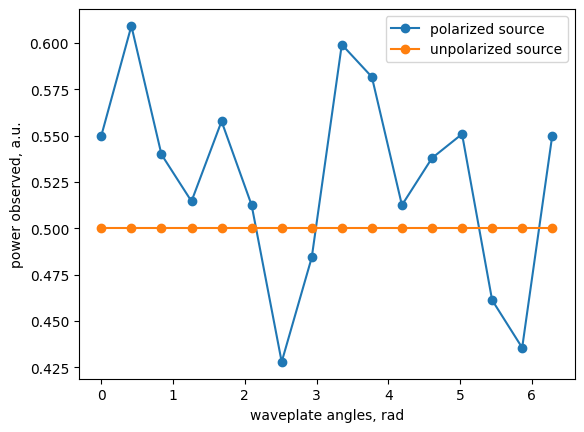

In [8]:
import matplotlib.pyplot as plt
stokes_pol = np.array([1, 0.1, 0.2, -0.1])
stokes_unpol = np.array([1, 0., 0., 0.])

# returns an ndarray if operated on with an ndarray
stokes_pol = stokes_polarimeter @ stokes_pol
stokes_unpol = stokes_polarimeter @ stokes_unpol

plt.figure()
plt.plot(angles, stokes_pol[..., 0], marker="o", label="polarized source")
plt.plot(angles, stokes_unpol[..., 0], marker="o", label="unpolarized source")
plt.xlabel("waveplate angles, rad")
plt.ylabel("power observed, a.u.")
plt.legend()
plt.show()

## Fitting a `Model` to Data 
To support optimization and statistical inference, we have a `Model` class that can simulate the power observed after a generally polarized source propagates through a system of Mueller matrices of arbitrary shape. Lets repeat this for the example of the Stokes polarimeter. The order is critical here, and will look "backwards" to some. 

Under the hood, Katsu is just looping over the optics in a list, meaning light (or your favorite stokes vector) encounters the first optic in the list, then the second, etc. 

We will start by generating our "truth" dataset using the standard `katsu` objects 

In [70]:
retarder = LinearRetarder.as_half_wave_plate(fast_axis=angles, shape=angles.shape)
polarizer = LinearDiattenuator.as_polarizer(0)
stokes = np.array([1., 0., 0.1, 0.])
stokes = polarizer @ retarder @ stokes
power_hwp = stokes[..., 0]

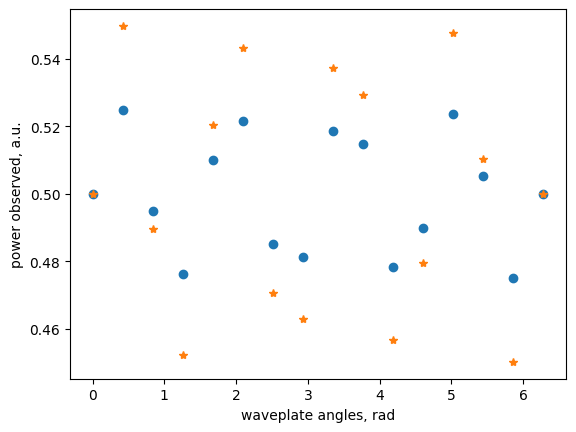

In [71]:

retarder = LinearRetarder.as_quarter_wave_plate(fast_axis=angles, shape=angles.shape)
polarizer = LinearDiattenuator.as_polarizer(0)
stokes = np.array([1., 0., 0.1, 0.])
stokes = polarizer @ retarder @ stokes
power_qwp = stokes[..., 0]

plt.figure()
plt.plot(angles, power_qwp, marker="o", linestyle="None")
plt.plot(angles, power_hwp, marker="*", linestyle="None")
plt.xlabel("waveplate angles, rad")
plt.ylabel("power observed, a.u.")
plt.show()

In the simplest case, let's say that we have some very good encoders that tell us the position of our waveplate, and we are quite confident that the waveplate is indeed a quarter-wave. However, a postdoc came into our lab and bumped the polarizer - oh no! Now we don't know what angle the polarizer is at!

Luckily, we are observing something with very well defined polarization. Let's use that to unpack what the angle of our polarizer is. We begin, by constructing a model of our system. Here we initialize a `Model` that accepts a list of the objects we've previously defined.

Here is where [Zodiax](https://github.com/LouisDesdoigts/zodiax) comes in to help out with optimization. One of the sharp bits about Jax is that arrays and objects are fundamentally immutable, and Zodiax exists to help us take gradients with ease. 

In [80]:
# Called dLux for now before integration starts officially
from katsu.models import dLuxModel, dLuxDiattenuator, dLuxRetarder

layers = [
    ('retarder', dLuxRetarder(angles, np.pi, shape=angles.shape)),
    ('diattenuator', dLuxDiattenuator(0, 0.1)),
]

system = dLuxModel(layers)

In [114]:
import optax
import zodiax as zdx
import equinox as eqx
from tqdm import tqdm

# Choose to solve for things. NOTE: params values must be jax arrays, not raw
# python floats. `eqx.filter_value_and_grad` only differentiates array leaves,
# so a bare float (e.g. np.pi) is treated as a static constant and its gradient
# comes back as None.

# Option 1: We can chose what parameters we want to start from
params = {
    "retardance": np.array(np.pi / 2),
    "Tmin": np.array(0.7),
}

# Option 2a: We can take our starting parameters from the model
# (`get(..., as_dict=True)` already casts the values to float arrays)
params = system.get(["retardance", "Tmin"], as_dict=True)

# Option 2b: We can take our starting parameters from the model.
# Wrap in np.array so the leaves are differentiable (the raw attributes are
# python floats).
params = {
    "retardance": np.array(system.retarder.retardance),
    "Tmin": np.array(system.diattenuator.Tmin)
}

optimizers = {
    "retardance": optax.adam(1e-2),
    "Tmin": optax.adam(1e-2)
}

optim, state = zdx.optimisation.map_optimisers(params, optimizers)

# Define a loss function
def loss_fn(params, model, stokes):
    model = model.set(params)
    out = model.forward(stokes)
    observed = out[..., 0]
    return np.sum((observed - power) ** 2)


loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn))
loss_grad_fn(params, system, np.array([1., 0., 0.1, 0.,]))


losses = []
for step in tqdm(range(1000)):
    loss, grads = loss_grad_fn(params, system, np.array([1., 0., 0.1, 0.]))
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    params["Tmin"] = np.clip(params["Tmin"], 1e-4, 1.0)
    losses.append(loss)


100%|██████████| 1000/1000 [00:02<00:00, 402.55it/s]


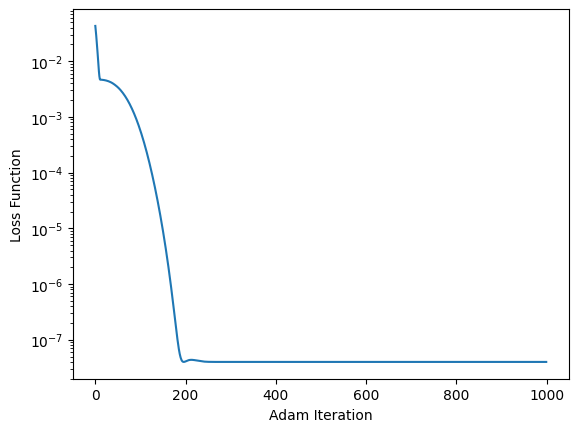

In [119]:
plt.plot(losses)
plt.ylabel("Loss Function")
plt.xlabel("Adam Iteration")
plt.yscale("log")

In [120]:
print(params)

{'Tmin': Array(0.0001, dtype=float64), 'retardance': Array(1.57089634, dtype=float64)}


## Posterior Sampling with Blackjax


In [ ]:
import blackjax

